In [34]:
import torch
import numpy as np
import matplotlib.pyplot as plt

In [35]:
from anomaly_detection.utils.load_sam_data import load_dataset
from anomaly_detection.utils.preprocess import drop_empty_histograms
from anomaly_detection.utils.preprocess import minmax_scale_per_sample

dataset = load_dataset("FJ")
full_dataset = np.array(dataset)
full_dataset = minmax_scale_per_sample(full_dataset)

dataset_no_outs = drop_empty_histograms(full_dataset)

Loading data from: C:\Users\hrdyj\coding\vyzkumak\data\FJ\FI01X1\FI01X1_ch
Dropped indexes [8, 15, 188, 214, 263, 268, 533, 546]


In [80]:
from anomaly_detection.utils.test_and_eval import HistGenerator

gen = HistGenerator(96)
# medium outliers
out = gen.zig_zag_rand(zero_indexes=[i for i in range(38,50)], one_indexes=[], real_sample=full_dataset[90])
out2 = gen.zig_zag_rand(zero_indexes=[], one_indexes=[i for i in range(70,90)], real_sample=full_dataset[90])
# strong outliers
out3 = gen.zig_zag_rand(zero_indexes=[i for i in range(10,90)], one_indexes=[], real_sample=full_dataset[90])
out4 = gen.zig_zag_rand(zero_indexes=[i for i in range(len(full_dataset[0]))], one_indexes=[i for i in range(35,66)], real_sample=full_dataset[90])
# weak outs
out5 = gen.zig_zag_rand(zero_indexes=[i for i in range(25,31)], one_indexes=[], real_sample=full_dataset[90])
out6 = gen.zig_zag_rand(zero_indexes=[], one_indexes=[i for i in range(0,5)], real_sample=full_dataset[90])

In [81]:
# normal points
norm = np.mean([full_dataset[0], full_dataset[1], full_dataset[3]], axis=0)
norm2 = np.mean([full_dataset[200], full_dataset[201], full_dataset[203]], axis=0)

# random
rand = torch.rand(96)
rand2 = torch.rand(96)

In [76]:
from anomaly_detection.config.paths import DATA_DIR
DATA_DIR / 'artificial'

WindowsPath('C:/Users/hrdyj/coding/vyzkumak/data/artificial')

In [ ]:
import pandas as pd
from anomaly_detection.config.paths import DATA_DIR

data = [
    # Random
    {"histogram": rand.tolist(), "category": "random"},
    {"histogram": rand2.tolist(), "category": "random"},
    # Strong
    {"histogram": out3.tolist(), "category": "strong"},
    {"histogram": out4.tolist(), "category": "strong"},
    # Medium
    {"histogram": out.tolist(), "category": "medium"},
    {"histogram": out2.tolist(), "category": "medium"},
    # Weak
    {"histogram": out5.tolist(), "category": "weak"},
    {"histogram": out6.tolist(), "category": "weak"}, 
    # Normal
    {"histogram": norm.tolist(), "category": "normal"},
    {"histogram": norm2.tolist(), "category": "normal"},
]

df = pd.DataFrame(data)
df.to_parquet("eval_dataset.parquet", engine="pyarrow", index=False)

print(f"Dataset uložený. Počet vzoriek: {len(df)}")

Dataset uložený. Počet vzoriek: 10


<BarContainer object of 96 artists>

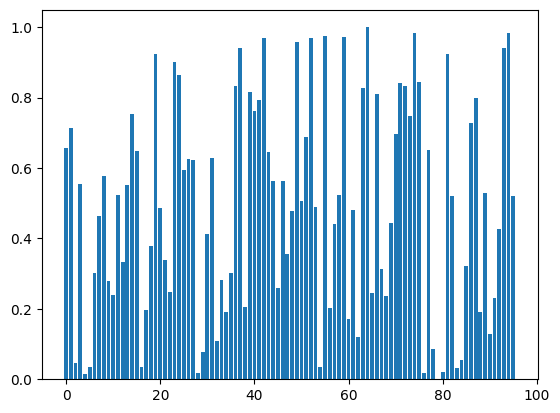

In [74]:
plt.bar(range(96), rand2)

1.0


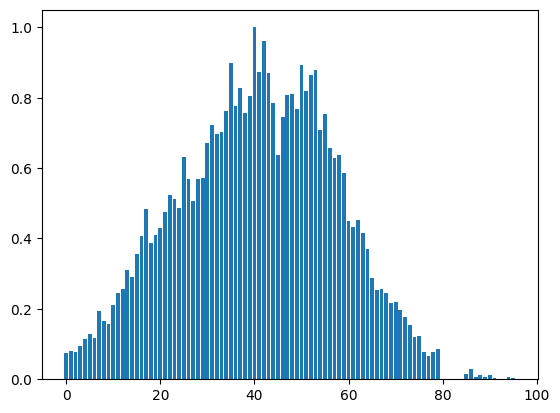

In [38]:
plt.bar(range(96), full_dataset[90])
print(max(full_dataset[90]))

In [39]:
from anomaly_detection.config.paths import CHECKPOINT_DIR
from anomaly_detection.models.conv_ae import ConvAE

checkpoint = torch.load(f"{CHECKPOINT_DIR}/conv_autoenc_v1.pth", map_location="cpu")

config = checkpoint["config"]

model = ConvAE()
model.load_state_dict(checkpoint["model_state_dict"])

model.eval()

ConvAE(
  (encoder): Sequential(
    (0): Conv1d(1, 1, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): BatchNorm1d(1, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv1d(1, 1, kernel_size=(3,), stride=(2,), padding=(1,))
    (4): BatchNorm1d(1, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Conv1d(1, 1, kernel_size=(3,), stride=(1,), padding=(1,))
    (7): BatchNorm1d(1, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU()
    (9): Conv1d(1, 1, kernel_size=(3,), stride=(2,), padding=(1,))
    (10): BatchNorm1d(1, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU()
    (12): Conv1d(1, 1, kernel_size=(3,), stride=(1,), padding=(1,))
    (13): BatchNorm1d(1, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): ReLU()
    (15): Conv1d(1, 1, kernel_size=(3,), stride=(2,), padding=(1,))
    (16): BatchNorm1d(1, eps=1e-05, mom

In [44]:
model(torch.tensor(full_dataset[0]).reshape(1,1,96))

tensor([[[0.1115, 0.1176, 0.1109, 0.1079, 0.1540, 0.1549, 0.1300, 0.1526,
          0.1395, 0.1725, 0.2013, 0.2007, 0.1740, 0.2691, 0.1962, 0.1907,
          0.2324, 0.3816, 0.3096, 0.3645, 0.3742, 0.2847, 0.3417, 0.3266,
          0.4626, 0.4863, 0.5065, 0.3481, 0.3721, 0.3989, 0.5649, 0.5415,
          0.6457, 0.6238, 0.6657, 0.7892, 0.6160, 0.7918, 0.7382, 0.6313,
          0.8813, 0.6072, 0.7934, 0.7047, 0.6604, 0.6284, 0.6797, 0.7278,
          0.7756, 0.8128, 0.8314, 0.7851, 0.8656, 0.8465, 0.7309, 0.8258,
          0.7465, 0.7245, 0.6488, 0.7136, 0.4105, 0.4203, 0.5198, 0.4525,
          0.2937, 0.3428, 0.3051, 0.2692, 0.2562, 0.2218, 0.2683, 0.2331,
          0.2521, 0.1907, 0.1797, 0.2967, 0.1512, 0.1509, 0.1427, 0.1410,
          0.0991, 0.0836, 0.1079, 0.0983, 0.1075, 0.0855, 0.0925, 0.1096,
          0.1032, 0.0958, 0.0940, 0.1150, 0.0920, 0.1004, 0.0890, 0.1085]]],
       grad_fn=<SigmoidBackward0>)

In [ ]:
# TODO: move it somewhere to autoencoders or sht
def score_points(pts, model, criterion=None):
    if not criterion:
        import torch
        criterion = torch.nn.MSELoss()

    out_scores = []
    for out in pts:
        out = out.reshape(1, 1, 96)
        pred = model(out).detach()
        loss = criterion(pred, out).detach().numpy()
        out_scores.append(loss)
        
    return out_scores

In [46]:
criterion = torch.nn.MSELoss()

out_scores = []
for out in full_dataset:
    out = torch.tensor(out)
    out = out.reshape(1, 1, 96)
    pred = model(out).detach()
    loss = criterion(pred, out).detach().numpy()
    out_scores.append(loss)

In [47]:
outliers = [out, out2, out3, out4, out5, out6]
fake_out_scores = []
for out in outliers:
    out = torch.tensor(out)
    out = out.reshape(1, 1, 96)
    pred = model(out).detach()
    loss = criterion(pred, out).detach().numpy()
    fake_out_scores.append(loss)

C:\Users\hrdyj\AppData\Local\Temp\ipykernel_8332\1569902080.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  out = torch.tensor(out)


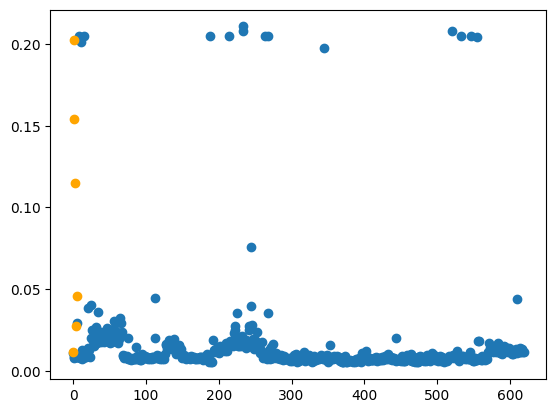

In [49]:
plt.scatter(range(len(out_scores)), out_scores)
plt.scatter(range(len(fake_out_scores)), fake_out_scores, color='orange')

In [72]:
pred = model(norm2:=torch.tensor(norm2).reshape(1,1,96)).detach().squeeze()
loss = torch.nn.MSELoss()
print(loss(norm2, pred).detach().numpy())


0.012095507


C:\Users\hrdyj\AppData\Local\Temp\ipykernel_8332\2377641085.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  pred = model(norm2:=torch.tensor(norm2).reshape(1,1,96)).detach().squeeze()
c:\Users\hrdyj\coding\vyzkumak\mlenv\Lib\site-packages\torch\nn\modules\loss.py:616: UserWarning: Using a target size (torch.Size([96])) that is different to the input size (torch.Size([1, 1, 96])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
